# 03 — Эксперименты
Сравниваем ансамблевые модели с baseline (Ridge, RMSE=0.483).
Порядок: RandomForest → XGBoost → LightGBM → Stacking → финальная оценка на тесте.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from src.preprocessing import set_seed, prepare_target, TARGET, SEED

set_seed()
BASELINE_RMSE = 0.4827  # Ridge val RMSE из 02_baseline

## 1. Загрузка данных

In [2]:
train = pd.read_csv('../data/processed/train.csv')
val   = pd.read_csv('../data/processed/val.csv')
test  = pd.read_csv('../data/processed/test.csv')

X_train, y_train = prepare_target(train)
X_val,   y_val   = prepare_target(val)
X_test,  y_test  = prepare_target(test)

X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Фичи: {list(X_train.columns)}')

Train: (13003, 22) | Val: (2786, 22) | Test: (2787, 22)
Фичи: ['P_Age', 'P_Overall', 'P_Potential', 'P_IntReputation', 'P_WeakFoot', 'P_SkillMoves', 'P_PaceTotal', 'P_ShootingTotal', 'P_PassingTotal', 'P_DribblingTotal', 'P_DefendingTotal', 'P_PhysicalityTotal', 'C_Overall', 'C_TransferBudget', 'C_DomesticPrestige', 'C_IntPrestige', 'Growth', 'OverallSquared', 'ContractYearsLeft', 'Club_Strength', 'LeagueRank', 'IsTopLeague']


## 2. Вспомогательные функции

In [3]:
results = []

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(
        np.abs((np.expm1(y_true) - np.expm1(y_pred)) / (np.expm1(y_true) + 1e-9))
    ) * 100
    print(f'{name:<30} RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f} | MAPE: {mape:.1f}%')
    results.append({'model': name, 'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape})
    return rmse


def plot_feature_importance(model, feature_names, title, top_n=15):
    imp = pd.Series(model.feature_importances_, index=feature_names)
    imp.sort_values(ascending=True).tail(top_n).plot(
        kind='barh', figsize=(10, 6), color='steelblue'
    )
    plt.title(title)
    plt.xlabel('Feature importance')
    plt.tight_layout()
    plt.show()


# Добавляем baseline как точку отсчёта
print(f'Baseline (Ridge val RMSE): {BASELINE_RMSE}')

Baseline (Ridge val RMSE): 0.4827


## 3. Random Forest
Ансамбль деревьев с бэггингом. Устойчив к выбросам, хорошо работает без масштабирования.
Ожидаем значительный прирост над линейными моделями за счёт улавливания нелинейностей.

In [4]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=4,
    n_jobs=-1,
    random_state=SEED,
)
rf.fit(X_train, y_train)
evaluate('RandomForest', y_val, rf.predict(X_val))

RandomForest                   RMSE: 0.3240 | MAE: 0.2232 | R²: 0.9393 | MAPE: 23.1%


np.float64(0.3239527873073379)

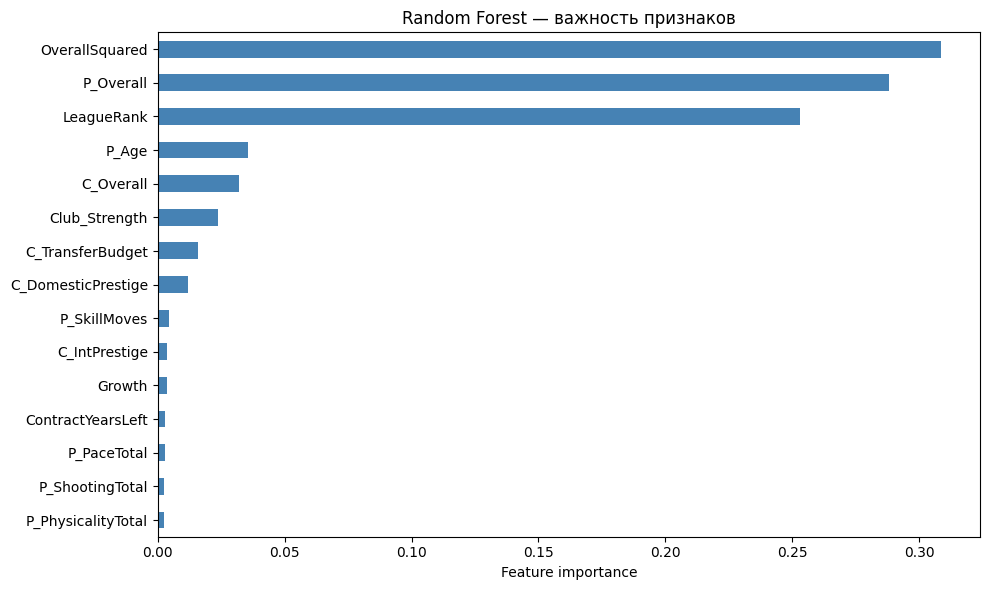

In [5]:
plot_feature_importance(rf, X_train.columns, 'Random Forest — важность признаков')

## 4. XGBoost
Градиентный бустинг. Как правило точнее RF за счёт последовательного исправления ошибок.
`subsample` и `colsample_bytree` — регуляризация, снижающая переобучение.

In [6]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)
xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)
evaluate('XGBoost', y_val, xgb.predict(X_val))

XGBoost                        RMSE: 0.2642 | MAE: 0.1724 | R²: 0.9596 | MAPE: 17.9%


np.float64(0.2641813154480035)

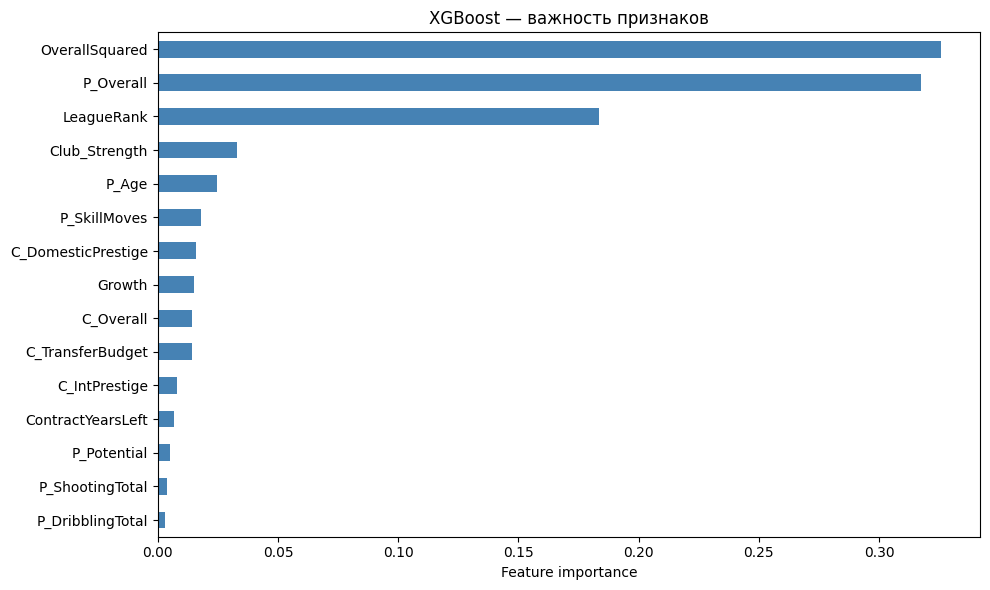

In [7]:
plot_feature_importance(xgb, X_train.columns, 'XGBoost — важность признаков')

## 5. LightGBM
Быстрее XGBoost на больших данных за счёт гистограммного разбиения.
`num_leaves` — главный параметр сложности (чем больше, тем глубже деревья).

In [8]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'num_leaves':        [31, 63, 127],
    'learning_rate':     [0.01, 0.03, 0.05, 0.1],
    'min_child_samples': [10, 20, 50],
    'subsample':         [0.7, 0.8, 0.9],
    'colsample_bytree':  [0.7, 0.8, 0.9],
}

lgbm_search = RandomizedSearchCV(
    LGBMRegressor(n_estimators=300, random_state=SEED, verbose=-1, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=SEED,
    n_jobs=-1,
)
lgbm_search.fit(X_train, y_train)

print('Лучшие параметры:', lgbm_search.best_params_)
print(f'CV RMSE: {-lgbm_search.best_score_:.4f}')

lgbm_tuned = lgbm_search.best_estimator_
evaluate('LightGBM (tuned)', y_val, lgbm_tuned.predict(X_val))


Лучшие параметры: {'subsample': 0.9, 'num_leaves': 63, 'min_child_samples': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
CV RMSE: 0.2741
LightGBM (tuned)               RMSE: 0.2626 | MAE: 0.1704 | R²: 0.9601 | MAPE: 17.5%


np.float64(0.262581472631265)

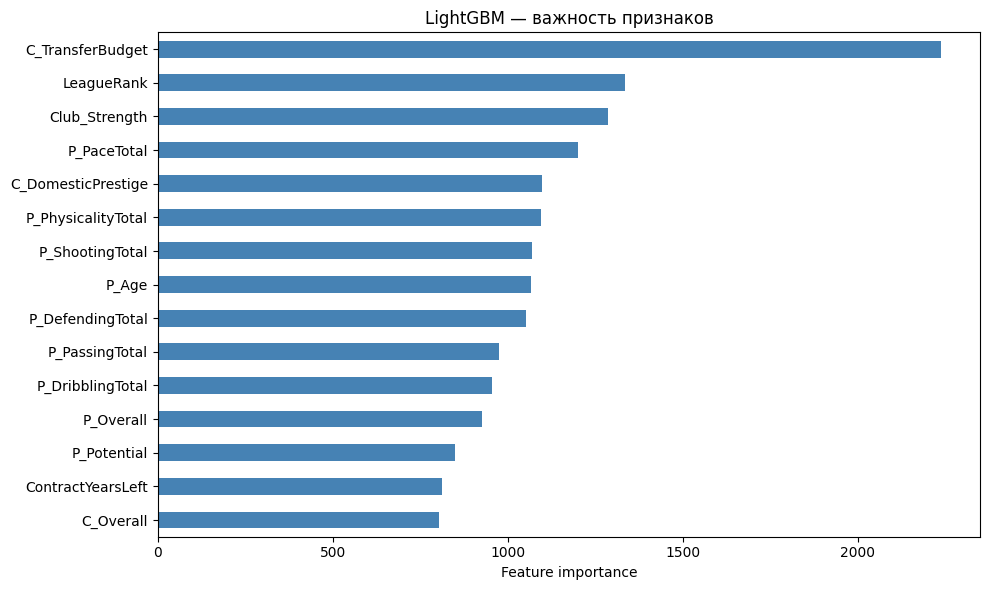

In [9]:
plot_feature_importance(lgbm_tuned, X_train.columns, 'LightGBM — важность признаков')

## 6. Stacking
Мета-модель обучается на предсказаниях базовых моделей.
Базовые: RF + XGBoost + LightGBM. Мета-модель: Ridge (простая и не переобучается).
`cv=5` — предсказания базовых моделей генерируются через кросс-валидацию, нет утечки.

In [10]:
stack = StackingRegressor(
    estimators=[
        ('rf',   RandomForestRegressor(
            n_estimators=200, max_depth=10, n_jobs=-1, random_state=SEED)
        ),
        ('xgb',  XGBRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=6,
            subsample=0.8, random_state=SEED, verbosity=0, n_jobs=-1)
        ),
        ('lgbm', LGBMRegressor(
            n_estimators=300, learning_rate=0.05, num_leaves=63,
            subsample=0.8, random_state=SEED, verbose=-1, n_jobs=-1)
        ),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1,
)
stack.fit(X_train, y_train)
evaluate('Stacking (RF+XGB+LGBM→Ridge)', y_val, stack.predict(X_val))

Stacking (RF+XGB+LGBM→Ridge)   RMSE: 0.2621 | MAE: 0.1721 | R²: 0.9602 | MAPE: 17.8%


np.float64(0.2620793844793623)

## 7. Сравнение всех моделей

In [11]:
results_df = pd.DataFrame(results).set_index('model').sort_values('rmse')
display(results_df.round(4))

,rmse,mae,r2,mape
model,,,,
Stacking (RF+XGB+LGBM→Ridge),0.2621,0.1721,0.9602,17.8445
LightGBM (tuned),0.2626,0.1704,0.9601,17.5496
XGBoost,0.2642,0.1724,0.9596,17.8546
RandomForest,0.3240,0.2232,0.9393,23.0562


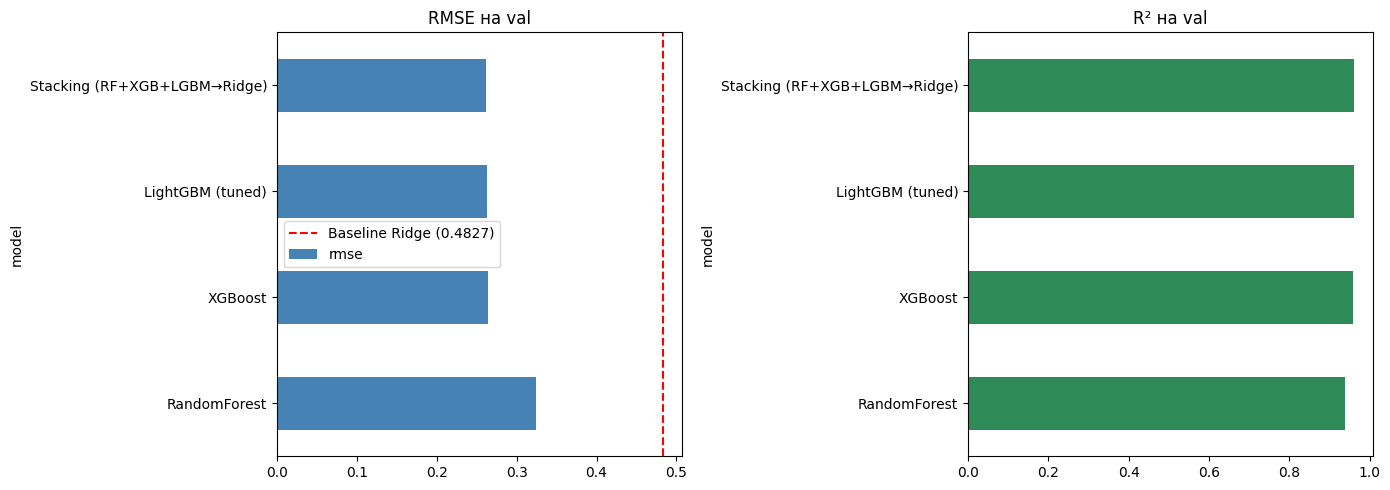

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df['rmse'].sort_values(ascending=False).plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].axvline(BASELINE_RMSE, color='red', linestyle='--', label=f'Baseline Ridge ({BASELINE_RMSE})')
axes[0].set_title('RMSE на val')
axes[0].legend()

results_df['r2'].sort_values().plot(
    kind='barh', ax=axes[1], color='seagreen'
)
axes[1].set_title('R² на val')

plt.tight_layout()
plt.show()

## 8. Финальная оценка лучшей модели на тесте
Тест используем **один раз** — только для финальной оценки лучшей модели.
Лучшая модель переобучается на train+val перед оценкой на тесте.

In [13]:
best_name = results_df['rmse'].idxmin()
print(f'Лучшая модель: {best_name}')

models_map = {
    'RandomForest': RandomForestRegressor(
        n_estimators=300, max_depth=12, min_samples_leaf=4,
        n_jobs=-1, random_state=SEED),
    'XGBoost': XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=SEED,
        verbosity=0, n_jobs=-1),
    'LightGBM': LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        subsample=0.8, random_state=SEED, verbose=-1, n_jobs=-1),
}

if 'Stacking' in best_name:
    best_model = stack
    best_model.fit(X_trainval, y_trainval)
else:
    best_model = models_map.get(best_name)
    if best_model:
        best_model.fit(X_trainval, y_trainval)

print('\n=== TEST SCORE (финальная оценка) ===')
evaluate(f'{best_name} [TEST]', y_test, best_model.predict(X_test))

Лучшая модель: Stacking (RF+XGB+LGBM→Ridge)

=== TEST SCORE (финальная оценка) ===
Stacking (RF+XGB+LGBM→Ridge) [TEST] RMSE: 0.2602 | MAE: 0.1657 | R²: 0.9608 | MAPE: 16.6%


np.float64(0.260247163146716)

## 9. Предсказания vs Реальные значения

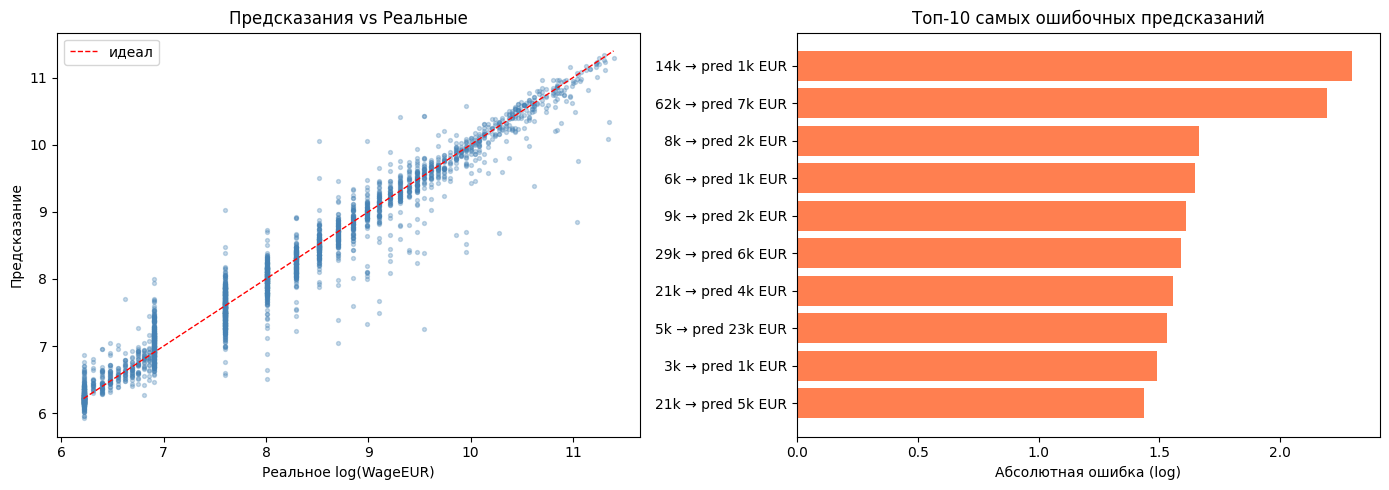

In [14]:
y_pred_test = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.3, s=8, color='steelblue')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1, label='идеал')
axes[0].set_xlabel('Реальное log(WageEUR)')
axes[0].set_ylabel('Предсказание')
axes[0].set_title('Предсказания vs Реальные')
axes[0].legend()

errors = np.abs(y_test.values - y_pred_test)
top_errors_idx = np.argsort(errors)[-10:]
err_df = X_test.iloc[top_errors_idx].copy()
err_df['real_log'] = y_test.values[top_errors_idx]
err_df['pred_log'] = y_pred_test[top_errors_idx]
err_df['error'] = errors[top_errors_idx]
err_df['real_EUR'] = np.expm1(err_df['real_log']).astype(int)
err_df['pred_EUR'] = np.expm1(err_df['pred_log']).astype(int)

axes[1].barh(range(10), err_df['error'].values, color='coral')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(
    [f"{r:.0f}k → pred {p:.0f}k EUR"
     for r, p in zip(err_df['real_EUR']/1000, err_df['pred_EUR']/1000)]
)
axes[1].set_xlabel('Абсолютная ошибка (log)')
axes[1].set_title('Топ-10 самых ошибочных предсказаний')

plt.tight_layout()
plt.show()

## 10. Сохранение лучшей модели

In [15]:
os.makedirs('../models', exist_ok=True)
model_path = f'../models/best_{best_name.split()[0].lower()}.joblib'
joblib.dump(best_model, model_path)
print(f'Модель сохранена: {model_path}')

results_df.round(4)

Модель сохранена: ../models/best_stacking.joblib


,rmse,mae,r2,mape
model,,,,
Stacking (RF+XGB+LGBM→Ridge),0.2621,0.1721,0.9602,17.8445
LightGBM (tuned),0.2626,0.1704,0.9601,17.5496
XGBoost,0.2642,0.1724,0.9596,17.8546
RandomForest,0.3240,0.2232,0.9393,23.0562


## Дополнительные эксперименты и визуализации

In [16]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from src.preprocessing import set_seed, prepare_target, TARGET, SEED

set_seed()
BASELINE_RMSE = 0.4827

In [17]:
from lightgbm import early_stopping, log_evaluation

lgbm = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(50, verbose=False), log_evaluation(-1)],
)
print(f'Best iteration: {lgbm.best_iteration_}')
evaluate('LightGBM', y_val, lgbm.predict(X_val))

Best iteration: 545
LightGBM                       RMSE: 0.2623 | MAE: 0.1698 | R²: 0.9602 | MAPE: 17.5%


np.float64(0.26232634753177464)

In [18]:
train = pd.read_csv('../data/processed/train.csv')
val   = pd.read_csv('../data/processed/val.csv')
test  = pd.read_csv('../data/processed/test.csv')

X_train, y_train = prepare_target(train)
X_val,   y_val   = prepare_target(val)
X_test,  y_test  = prepare_target(test)

# Объединяем train+val для финального обучения лучшей модели
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Фичи: {list(X_train.columns)}')

Train: (13003, 22) | Val: (2786, 22) | Test: (2787, 22)
Фичи: ['P_Age', 'P_Overall', 'P_Potential', 'P_IntReputation', 'P_WeakFoot', 'P_SkillMoves', 'P_PaceTotal', 'P_ShootingTotal', 'P_PassingTotal', 'P_DribblingTotal', 'P_DefendingTotal', 'P_PhysicalityTotal', 'C_Overall', 'C_TransferBudget', 'C_DomesticPrestige', 'C_IntPrestige', 'Growth', 'OverallSquared', 'ContractYearsLeft', 'Club_Strength', 'LeagueRank', 'IsTopLeague']


In [19]:
lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[],
)
evaluate('LightGBM', y_val, lgbm.predict(X_val))

LightGBM                       RMSE: 0.2629 | MAE: 0.1704 | R²: 0.9600 | MAPE: 17.6%


np.float64(0.26285682106021063)

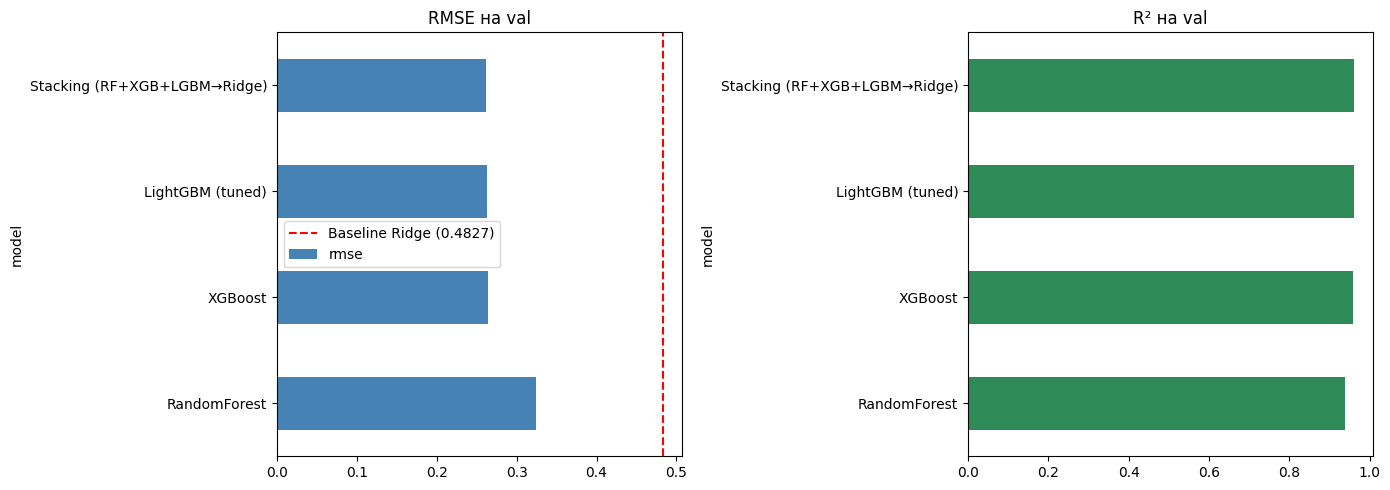

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df['rmse'].sort_values(ascending=False).plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].axvline(BASELINE_RMSE, color='red', linestyle='--', label=f'Baseline Ridge ({BASELINE_RMSE})')
axes[0].set_title('RMSE на val')
axes[0].legend()

results_df['r2'].sort_values().plot(
    kind='barh', ax=axes[1], color='seagreen'
)
axes[1].set_title('R² на val')

plt.tight_layout()
plt.show()

In [21]:
# Выбираем лучшую модель по val RMSE
best_name = results_df['rmse'].idxmin()
print(f'Лучшая модель: {best_name}')

# Переобучаем на train+val
models_map = {
    'RandomForest': RandomForestRegressor(
        n_estimators=300, max_depth=12, min_samples_leaf=4,
        n_jobs=-1, random_state=SEED),
    'XGBoost': XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=SEED,
        verbosity=0, n_jobs=-1),
    'LightGBM': LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        subsample=0.8, random_state=SEED, verbose=-1, n_jobs=-1),
}

# Если лучшая — стэкинг, обучаем его, иначе берём из словаря
if 'Stacking' in best_name:
    best_model = stack
    best_model.fit(X_trainval, y_trainval)
else:
    best_model = models_map.get(best_name)
    if best_model:
        best_model.fit(X_trainval, y_trainval)

print('\n=== TEST SCORE (финальная оценка) ===')
evaluate(f'{best_name} [TEST]', y_test, best_model.predict(X_test))

Лучшая модель: Stacking (RF+XGB+LGBM→Ridge)

=== TEST SCORE (финальная оценка) ===
Stacking (RF+XGB+LGBM→Ridge) [TEST] RMSE: 0.2602 | MAE: 0.1657 | R²: 0.9608 | MAPE: 16.6%


np.float64(0.260247163146716)

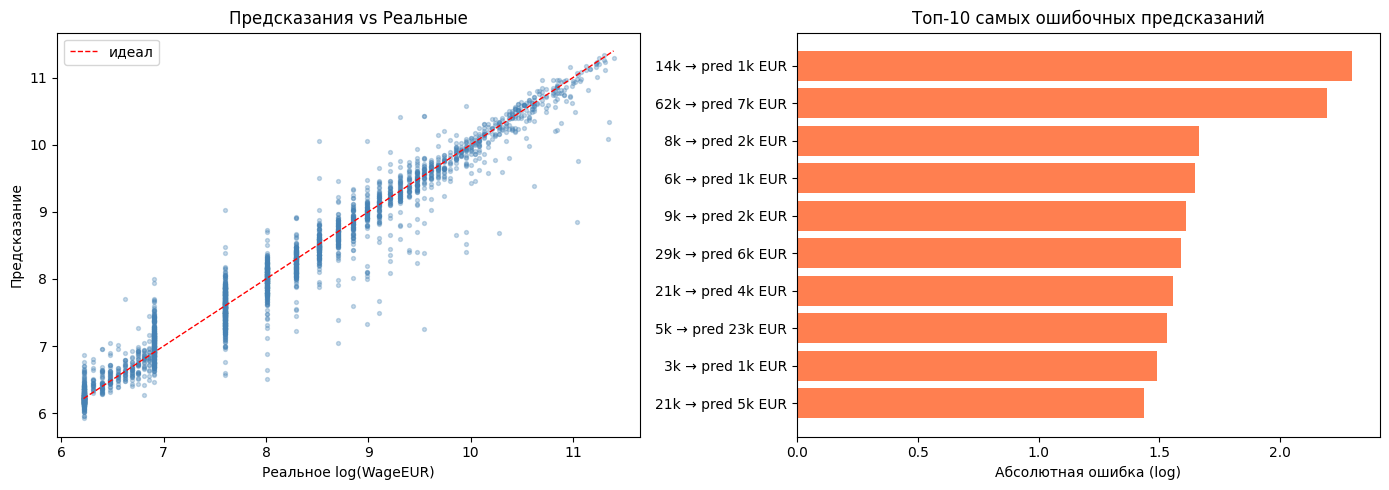

In [22]:
y_pred_test = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: предсказания vs реальные
axes[0].scatter(y_test, y_pred_test, alpha=0.3, s=8, color='steelblue')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1, label='идеал')
axes[0].set_xlabel('Реальное log(WageEUR)')
axes[0].set_ylabel('Предсказание')
axes[0].set_title('Предсказания vs Реальные')
axes[0].legend()

# Топ-10 самых ошибочных предсказаний
errors = np.abs(y_test.values - y_pred_test)
top_errors_idx = np.argsort(errors)[-10:]
err_df = X_test.iloc[top_errors_idx].copy()
err_df['real_log'] = y_test.values[top_errors_idx]
err_df['pred_log'] = y_pred_test[top_errors_idx]
err_df['error'] = errors[top_errors_idx]
err_df['real_EUR'] = np.expm1(err_df['real_log']).astype(int)
err_df['pred_EUR'] = np.expm1(err_df['pred_log']).astype(int)

axes[1].barh(range(10), err_df['error'].values, color='coral')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(
    [f"{r:.0f}k → pred {p:.0f}k EUR"
     for r, p in zip(err_df['real_EUR']/1000, err_df['pred_EUR']/1000)]
)
axes[1].set_xlabel('Абсолютная ошибка (log)')
axes[1].set_title('Топ-10 самых ошибочных предсказаний')

plt.tight_layout()
plt.show()

In [24]:
os.makedirs('../models', exist_ok=True)
model_path = f'../models/best_{best_name.split()[0].lower()}.joblib'
joblib.dump(best_model, model_path)
print(f'Модель сохранена: {model_path}')

print('Таблица экспериментов')
results_df.round(4)


Модель сохранена: ../models/best_stacking.joblib
Таблица экспериментов


,rmse,mae,r2,mape
model,,,,
Stacking (RF+XGB+LGBM→Ridge),0.2621,0.1721,0.9602,17.8445
LightGBM (tuned),0.2626,0.1704,0.9601,17.5496
XGBoost,0.2642,0.1724,0.9596,17.8546
RandomForest,0.3240,0.2232,0.9393,23.0562
